In [19]:
from typing import List, Tuple
from math import sqrt
import numpy as np
import scipy.linalg as la
import scipy.sparse.linalg as sla
from scipy.sparse import csr_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openfermion as of

In [20]:
n_occ = 2 # Number of fermions in the system
l = 2 # Size of square lattice
u = 1.0 # Coulomb repulsion
t = 0.5 # Tunneling
ham_fermi = of.hamiltonians.fermi_hubbard(
    l, l, t, u, periodic=False, spinless=True
)
ham_qubop = of.transforms.jordan_wigner(ham_fermi)
nq = of.utils.count_qubits(ham_qubop)

## Exact diagonalization

In [21]:
def total_number_qubit_operator(n_orbitals: int, use_jw=True) -> of.QubitOperator:
    """Get a Pauli sum representing the total number operator.
    
    Arugments:
    n_orbitals - Number of orbitals in the system.
    use_jw - Whether to use Jordan-Wigner. Otherwise, use Bravyi-Kitaev.
    
    Returns:
    A QubitOperator representation of the total number operator."""

    total_number = of.FermionOperator.zero()
    for i in range(n_orbitals):
        total_number += of.FermionOperator(f"{i}^ {i}", 1.0)
    if use_jw:
        total_number_qubit = of.transforms.jordan_wigner(total_number)
    else:
        total_number_qubit = of.transforms.bravyi_kitaev(total_number)
    return total_number_qubit

In [22]:
def expectation_and_variance(psi, observable):
    exp = np.vdot(psi, observable @ psi)
    exp2 = np.vdot(psi, observable ** 2 @ psi)
    var = exp2 - (exp ** 2)
    return (exp.real, var.real)

In [23]:
# Get the exact ground state
total_number_qubop = total_number_qubit_operator(nq)
total_number_sparse = of.linalg.get_sparse_operator(total_number_qubop)
alpha = 1e-0 # Regularzation paramter
ham_augmented = ham_qubop + alpha * (total_number_qubop - n_occ) ** 2
ham_augmented_sparse = of.linalg.get_sparse_operator(ham_augmented)
ham_sparse = of.linalg.get_sparse_operator(ham_qubop)
print(f"Shape of Hamiltonian matrix is {ham_sparse.shape} and {nq} qubits.")
evals, evecs = sla.eigsh(ham_augmented_sparse, which='SA')
min_index = np.argmin(evals)
ground_state = evecs[:, min_index]
ground_state /= la.norm(ground_state)
ground_energy, ground_energy_var = expectation_and_variance(ground_state, ham_sparse)
ground_number, ground_number_var = expectation_and_variance(ground_state, total_number_sparse)
print(f"Exact E_0={ground_energy}")
print(f"Var[E] = {ground_energy_var}")
print(f"<N> ={ground_number}")
print(f"Var[N] = {ground_number_var}")

Shape of Hamiltonian matrix is (16, 16) and 4 qubits.
Exact E_0=-0.618033988749895
Var[E] = -1.1102230246251565e-16
<N> =2.000000000000001
Var[N] = -1.7763568394002505e-15


In [24]:
# Above we added a term to ensure the ground state will have a number fermions.
# Let's remove it to get the "zero point energy"

evals, evecs = sla.eigsh(ham_sparse, which='SA')
min_idx = np.argmin(evals)
vacuum_state = evecs[:, min_idx]
vacuum_state /= la.norm(vacuum_state)

vacuum_energy, vacuum_energy_var = expectation_and_variance(vacuum_state, ham_sparse)
vacuum_number, vacuum_number_var = expectation_and_variance(vacuum_state, total_number_sparse)

print(f"E_vacuum = {vacuum_energy}")
print(f"Var[E] = {vacuum_energy_var}")
print(f"<N> ={vacuum_number}")
print(f"Var[N] = {vacuum_number_var}")

E_vacuum = -1.0
Var[E] = 0.0
<N> =1.0
Var[N] = 0.0


## Krylov

In [25]:
# Function for Krylov

def exact_overlaps(psi0, ham_sparse, d, dt):
    """Get the overlaps and matrix elements by exact exponentiation of the sparse Hamiltonain."""

    u = sla.expm(complex(0., -1.) * dt * ham_sparse)
    overlaps = []
    matrix_elements = []
    psi = psi0.copy()
    for _ in range(d):
        overlaps.append(np.vdot(psi0, psi))
        matrix_elements.append(np.vdot(psi0, ham_sparse @ psi))
        psi = u @ psi
    return overlaps, matrix_elements


def fill_subspace_matrices(
    mat_elems: List[complex], overlaps: List[complex]
) -> Tuple[np.ndarray, np.ndarray]:
    """Fill subspace matrices from the computed matrix elements and overlaps."""

    assert len(mat_elems) == len(overlaps)
    d = len(mat_elems)
    h = np.zeros((d, d), dtype=complex)
    s = np.zeros((d, d), dtype=complex)
    for i in range(d): # Loop over rows.
        for j in range(d):
            if i == j:
                h[i, i] = mat_elems[0]
                s[i, i] = overlaps[0]
            elif i > j:
                h[i, j] = mat_elems[i - j]
                s[i, j] = overlaps[i - j]
            else: # i < j
                h[i, j] = mat_elems[j - i].conjugate()
                s[i, j] = overlaps[j - i].conjugate()
    return h, s


def subspace_matrices(psi0, ham_sparse, d, dt):
    """Get subspace matrices by exact exponentiation"""

    overlaps, matrix_elements = exact_overlaps(psi0, ham_sparse, d, dt)
    h, s = fill_subspace_matrices(matrix_elements, overlaps)
    return h, s


def threshold_eigenvalues(h: np.ndarray, s: np.ndarray, eps: float) -> Tuple[np.ndarray, np.ndarray]:
    """Remove all eigenvalues below a positive threshold eps.
    See Epperly et al. sec. 1.2."""

    # Build a matrix whose columns correspond to the positive eigenvectors of s.
    evals, evecs = la.eigh(s)
    positive_evals = []
    positive_evecs = []
    for i, ev in enumerate(evals):
        assert abs(ev.imag) < 1e-7
        if ev.real > eps:
            positive_evals.append(ev.real)
            positive_evecs.append(evecs[:, i])
    pos_evec_mat = np.vstack(positive_evecs).T
    # Project h and s into this subspace.
    new_s =  pos_evec_mat.conj().T @ s @ pos_evec_mat
    new_h = pos_evec_mat.conj().T @ h @ pos_evec_mat
    return new_h, new_s


def krylov_energy(h, s, eps):
    new_h, new_s = threshold_eigenvalues(h, s, eps)
    evals, evecs = la.eig(new_h, new_s)
    min_idx = np.argmin(evals)
    return evals[min_idx]


def energy_vs_d(h, s, eps):
    assert h.shape == s.shape
    assert h.shape[0] == h.shape[1]
    d_max = h.shape[0]
    ds = list(range(1, d_max))
    energies = []
    for d in ds:
        h_d = h[:d, :d]
        s_d = s[:d, :d]
        energy = krylov_energy(h_d, s_d, eps)
        energies.append(energy.real)
    return (ds, energies)

In [26]:
# Function for projecting a state onto a certain symmetry.

def symmetry_projector(observable_sparse, eigval, tol=1e-8, ortho_tol=1e-8, var_tol=1e-8):
    """Build a projector onto the eigenvectors with a chosen
    eigenvalue."""

    observable_dense = observable_sparse.todense()
    evals, evecs = la.eig(observable_dense)
    correct_evecs = [] # Eigenvectors with correct eigenvalues
    for i in range(evals.size):
        if abs(evals[i] - eigval) <= tol:
            correct_evecs.append(evecs[:, i] / la.norm(evecs[:, i]))
    print(f"Keeping {len(correct_evecs)} states")
    evecs_mat = np.array(correct_evecs).T
    qr_result = la.qr(evecs_mat)
    q = qr_result[0]
    projector = np.zeros((evecs.shape[0], evecs.shape[0]), dtype=complex)
    for i in range(q.shape[1]):
        if i < len(correct_evecs):
            vec = q[:, i] / la.norm(q[:, i])
            vec = vec.reshape((vec.size,1))

            # Assert that this vector is ortho. to the others.
            for j in range(len(correct_evecs)):
                if j != i:
                    assert abs(np.vdot(vec, q[:, j])) <= ortho_tol

            exp, var = expectation_and_variance(vec, observable_sparse)
            assert abs(exp - eigval) <= tol
            assert abs(var) <= tol
            p = vec @ vec.conj().T
            projector += p
    return projector

In [27]:
z = np.array([[1., 0.], [0., -1.]])
z_sparse = csr_matrix(z)
proj = symmetry_projector(z_sparse, 1.0)
print(proj)
print(la.norm(proj @ proj - proj))
print(la.norm(proj.conj().T - proj))

Keeping 1 states
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
0.0
0.0


In [28]:
ref = np.random.normal(0, 1, 2 ** nq)
ref /= la.norm(ref)
number_projector = symmetry_projector(total_number_sparse, n_occ)
ref_projected = number_projector @ ref
ref_projected /= la.norm(ref_projected)

ref_number, ref_number_var = expectation_and_variance(ref, total_number_sparse)
ref_proj_number, ref_proj_num_var = expectation_and_variance(ref_projected, total_number_sparse)

print("Unprojected reference:")
print(f"<N> = {ref_number}")
print(f"Var[N] = {ref_number_var}")
print("Projected reference:")
print(f"<N> = {ref_proj_number}")
print(f"Var[N] = {ref_proj_num_var}")

Keeping 6 states
Unprojected reference:
<N> = 1.9063782610019788
Var[N] = 1.0967803287814277
Projected reference:
<N> = 1.9999999999999998
Var[N] = 4.440892098500626e-16


In [29]:
fidelity = abs(np.vdot(ground_state, ref_projected))
vacuum_fidelity = abs(np.vdot(vacuum_state, ref_projected))
print(f"F = {fidelity}")
print(f"F_vac = {vacuum_fidelity}")

F = 0.525245481770638
F_vac = 7.762947814374319e-17


In [30]:
d = 10
dt = 1e-1
eps = 1e-8
h, s = subspace_matrices(ref_projected, ham_sparse, d, dt)
e_krylov = krylov_energy(h, s, eps).real
print(f"Krylov energy = {e_krylov}")
print(f"Delta E = {ground_energy - e_krylov}")

Krylov energy = -0.6180339887499093
Delta E = 1.432187701766452e-14


In [31]:
h_bad, s_bad = subspace_matrices(ref, ham_sparse, d, dt)
e_krylov_bad = krylov_energy(h_bad, s_bad, eps).real
print(f"Krylov energy = {e_krylov_bad}")
print(f"Delta E = {ground_energy - e_krylov_bad}")

Krylov energy = -0.9481290044444121
Delta E = 0.33009501569451705


Create a superposition state $\sqrt{r} |GS\rangle + \sqrt{1-r} |rand\rangle$, where $0 \leq r \leq 1$ and $|rand\rangle$ is a random state.
Plot energy vs. $r$ for projected and unprojected states.

In [32]:
rs = np.linspace(0., 1., num=10)
r_energies_map = {}
for r in rs:
    # Do it with the bad state.
    psi_bad = sqrt(r) * ground_state + sqrt(1 - r) * ref
    h_bad, s_bad = subspace_matrices(psi_bad, ham_sparse, d, dt)
    ds_bad, energies_bad = energy_vs_d(h_bad, s_bad, eps)
    # Do it with the good state.
    psi_good = sqrt(r) * ground_state + sqrt(1 - r) * ref_projected
    h_good, s_good = subspace_matrices(psi_good, ham_sparse, d, dt)
    ds_good, energies_good = energy_vs_d(h_good, s_good, eps)
    assert ds_good == ds_bad
    r_energies_map[r] = {"ds": ds_good, "e_bad": energies_bad, "e_good": energies_good}

In [36]:
records = [] # Rows of dataframe
for r, energy_dict in r_energies_map.items():
    ds = energy_dict["ds"]
    e_bad = energy_dict["e_bad"]
    e_good = energy_dict["e_good"]
    for dd, eb, eg in zip(ds, e_bad, e_good):
        records.append((r, dd, eb, eg))
df = pd.DataFrame.from_records(records, columns=["r", "d", "bad_energy", "good_energy"])
df["error_bad"] = np.abs(df["bad_energy"] - ground_energy)
df["error_good"] = np.abs(df["good_energy"] - ground_energy)
print(df.head())

     r  d  bad_energy  good_energy  error_bad    error_good
0  0.0  1    0.757811     0.449985   1.375845  1.068019e+00
1  0.0  2   -0.289155    -0.554416   0.328879  6.361761e-02
2  0.0  3   -0.715430    -0.618034   0.097396  2.606360e-12
3  0.0  4   -0.853513    -0.618034   0.235479  9.015011e-14
4  0.0  5   -0.852544    -0.618034   0.234510  6.150636e-14


<Axes: xlabel='r', ylabel='error_good'>

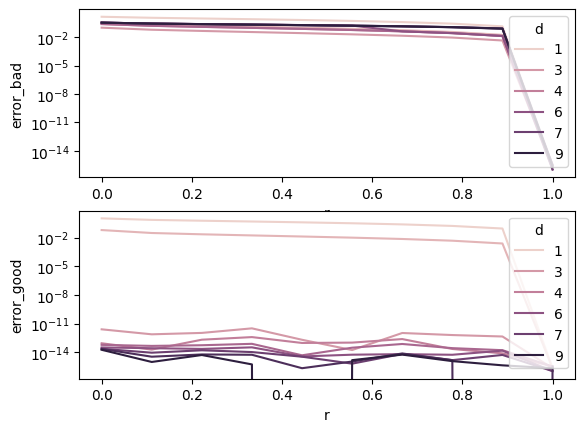

In [38]:
fig, ax = plt.subplots(2, 1)
ax[0].set_yscale('log')
ax[1].set_yscale('log')
sns.lineplot(ax=ax[0], data=df, x="r", y="error_bad", hue="d")
sns.lineplot(ax=ax[1], data=df, x="r", y="error_good", hue="d")